## AI4Climate ML tutorial - Evaluating ERA5 autoencoder
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

So far we have been working data in tabular format when training machine learning algorithms. We have previously encountered **gridded data**, but previously we converted this into a tabular format before using it with machine learning tools. In this notebook we will load a pre-trained autoencoder trained on era5 fields and evaluate the performance.





### Prerequisites 
- Same as previous  notebooks
- Have completed the training pipeline, inference and evaluation notebooks.
- Have run the autencoder tr


### Learning outcomes from completing the notebook

- Understand how to iterate through a gridded dataset for training
- Understand  how to create a convolutional neural network to work with gridded data.
- Understand how to evaluate gridded output for a regression type problem.

## Tutorial - Creating a machine learning pipe

Further Reading
* [PyTorch Docs](https://pytorch.org/)

### Environment 
This notebook uses the environment defined in this repository in the [requirements.txt](../requirements.txt) file (venv) or [requirements.yaml](../requirements.yaml).  

## Tutorial 
a balance of explanation and activity



#### Import libraries
Key libraries for this tutorial include:
- Xarray for loading the input dataset
- scikit learn for preparing the data for training
- pytorch for creating and training the neural network
- matplotlib and cartopy for visualising the results
- scores for evaluating model performance

In [199]:
import warnings
warnings.filterwarnings('ignore')

In [90]:
import pathlib
import os
import datetime
import json
import re
import copy
import sys

In [2]:
import numpy 
import xarray

In [3]:
import matplotlib
import matplotlib.pyplot
import cartopy.crs

In [4]:
import sklearn
import sklearn.preprocessing
import sklearn.tree


In [5]:
import mlflow

In [6]:
import torch

In [7]:
import scores

In [8]:
era5_ae_src_path = pathlib.Path('.').absolute().parent / 'src'/ 'ai4c_hack'
sys.path.append(str(era5_ae_src_path))


In [31]:
from  ERA5_autoencoder import Era5AutoEncoder

### Specify the experiment setup

Next we specify the experiment parameters through the config file anmd specifying other elementsm like file paths.

The tutorial config from the JSON file.

In [10]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25a/mmh_storage/ai4c_data/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer

In [13]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'weatherbench'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'weatherbench'
    return root_path

In [14]:
current_platform = tutorial_config['platform']

In [15]:
current_platform

'jasmin'

In [16]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench')

Define the key parameters for this experiment.

In [17]:
resolution_dict = {5.625: '5.625deg'}

In [18]:
mlready_dir = root_data_dir / 'mlready'

In [19]:
weatherbench_dir = mlready_dir / 'orig'
print(weatherbench_dir.is_dir())
weatherbench_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/mlready/orig')

In [20]:
wb_arco_path = mlready_dir / 'norm'
print(wb_arco_path.is_dir())
wb_arco_path

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/mlready/norm')

In [21]:
xarray.open_zarr(weatherbench_dir)

/gws/ssde/j25a/mmh_storage/user/shaddad/venv/ai4c_nb_gpu/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


<xarray.Dataset> Size: 66GB
Dimensions:              (time: 324337, level: 5, lat: 32, lon: 64)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1980-01-01 ... 2016-12-31
  * level                (level) int32 20B 1000 850 700 500 200
  * lat                  (lat) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * lon                  (lon) float64 512B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    geopotential         (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    specific_humidity    (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    temperature          (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    u_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    v_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

### Create data objects
Next we create a Pytorch dataset class, as we did for the previous tutorial. This is a key area of difference from tabular, because we will and access and prepare the data here quite differently from what we had previously. The class still needs to itersate over the data point, but now instead of rows being data points and columns being features, we have a multi-dimensional aray. Typically in problems like this, the dimensions of the aray correspond to xarray dataset as follows:
- dimension 0 - number of data point in a mini batch
- dimension 1 - the number of variables (also called channels) in a data point.
- dimension 2 - latitude
- dimension 3 - longitude

In [22]:
train_interval = (
    datetime.datetime(1980,1,1,0,0),
    datetime.datetime(2014,1,1,0,0),
)
val_interval = (
    datetime.datetime(2014,1,1,0,0),
    datetime.datetime(2016,1,1,0,0),
)

In [23]:
var_subset = ['temperature', 'geopotential']
pl_subset = [200, 500, 700, 850,1000]  
num_channels = len(var_subset) * len(pl_subset)

In [24]:
batch_size=16

In [25]:
(wb_train_ds, wb_train_loader, wb_val_ds, wb_val_loader) = ERA5_autoencoder.create_data_loaders(
    wb_arco_path, 
    var_subset,
    pl_subset,
    16,
    train_interval,
    val_interval,
)

num channels: 10
length train: 298057; length validation: 17521


In [26]:
wb_train_ds.num_channels

10

In [27]:
wb_val_loader.batch_size

16

In [28]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [29]:
model_dir = pathlib.Path('/gws/ssde/j25a/mmh_storage/user/shaddad/experiments/era5_autoencoder/run_20260701_1211/')
model_fname = 'era5_autoencoder_checkoint_014.pth'
model_path = model_dir / model_fname
print(model_path.is_file())
model_path

True


PosixPath('/gws/ssde/j25a/mmh_storage/user/shaddad/experiments/era5_autoencoder/run_20260701_1211/era5_autoencoder_checkoint_014.pth')

In [32]:
ae_model = torch.load(model_path, 
                      weights_only=False,
                      map_location=torch.device('cpu'),
                     )
ae_model

Era5AutoEncoder(
  (_encoder): Sequential(
    (0): Conv2d(10, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (_decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 10, kernel_size=(2, 2), stride=(2, 2))
  )
)

## Denormalising the data
The predictions coming out of the model will normalised, as was the training data. We want to see the values in the original units, so we need to reverse the normalisation. The code belows shows how we can check our denomralisation gives us the values we expect by comparing a denormalised array to values in the orignal data before normalisation was applied.

In [33]:
stats_path = mlready_dir / 'stats.json'

In [34]:
with open(stats_path,'r') as stats_file:
    stats_dict = json.load(stats_file)
stats_dict

{'temperature': {'mean': [281.00140380859375,
   274.55267333984375,
   267.38201904296875,
   252.93836975097656,
   218.0356903076172],
  'std': [17.117088317871094,
   15.580572128295898,
   14.770453453063965,
   13.066621780395508,
   7.193727493286133]},
 'specific_humidity': {'mean': [0.007025435566902161,
   0.004566648509353399,
   0.0024279849603772163,
   0.0008522787829861045,
   1.9398579752305523e-05],
  'std': [0.005913375411182642,
   0.004104434512555599,
   0.002542734844610095,
   0.0010768964421004057,
   2.262131602037698e-05]},
 'u_component_of_wind': {'mean': [-0.06702224165201187,
   1.3955833911895752,
   3.3002498149871826,
   6.556752681732178,
   14.211994171142578],
  'std': [6.1425700187683105,
   8.187788963317871,
   9.2008056640625,
   11.98122501373291,
   17.673219680786133]},
 'v_component_of_wind': {'mean': [0.2201852649450302,
   0.16798953711986542,
   0.0412067212164402,
   -0.02302303910255432,
   -0.0445253811776638],
  'std': [5.31966018676757

In [35]:
mean_vec = numpy.concat([numpy.array(stats_dict[var_name]['mean']) for var_name in var_subset])
std_vec = numpy.concat([numpy.array(stats_dict[var_name]['std']) for var_name in var_subset])

In [36]:
wb_val_ds._ds_norm.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array('2014-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2014-01-01
Attributes:
    long_name:  time

In [37]:
sample_time = '2014-01-01 00:00'

In [38]:
sample_input = wb_val_ds._ds_norm.sel(time=sample_time)
sample_input

<xarray.Dataset> Size: 83kB
Dimensions:       (level: 5, lat: 32, lon: 64)
Coordinates:
  * level         (level) int32 20B 1000 850 700 500 200
  * lat           (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon           (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    time          datetime64[ns] 8B 2014-01-01
Data variables:
    temperature   (level, lat, lon) float32 41kB dask.array<chunksize=(5, 32, 64), meta=np.ndarray>
    geopotential  (level, lat, lon) float32 41kB dask.array<chunksize=(5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [39]:
sample_shape = dict(sample_input.dims)
sample_shape

/tmp/ipykernel_1567/4279960985.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sample_shape = dict(sample_input.dims)


{'level': 5, 'lat': 32, 'lon': 64}

In [40]:
sample_input_arr = numpy.stack([sample_input[v1] for v1 in sample_input.data_vars]).reshape([num_channels, sample_shape['lat'], sample_shape['lon']])

In [41]:
orig_ds = xarray.open_zarr(weatherbench_dir)
orig_ds

<xarray.Dataset> Size: 66GB
Dimensions:              (time: 324337, level: 5, lat: 32, lon: 64)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1980-01-01 ... 2016-12-31
  * level                (level) int32 20B 1000 850 700 500 200
  * lat                  (lat) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * lon                  (lon) float64 512B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    geopotential         (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    specific_humidity    (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    temperature          (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    u_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    v_component_of_wind  (time, level, lat, lon) float32 13GB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [42]:
sample_data_orig = orig_ds[var_subset].sel(time=sample_time)

In [43]:
sample_data_orig

<xarray.Dataset> Size: 83kB
Dimensions:       (level: 5, lat: 32, lon: 64)
Coordinates:
  * level         (level) int32 20B 1000 850 700 500 200
  * lat           (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon           (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    time          datetime64[ns] 8B 2014-01-01
Data variables:
    temperature   (level, lat, lon) float32 41kB dask.array<chunksize=(5, 32, 64), meta=np.ndarray>
    geopotential  (level, lat, lon) float32 41kB dask.array<chunksize=(5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [44]:
sample_orig_arr = numpy.stack([sample_data_orig[v1] for v1 in sample_data_orig.data_vars]).reshape([num_channels, sample_shape['lat'], sample_shape['lon']])

In [45]:
sample_orig_arr

array([[[   262.84872,    262.80475,    262.8001 , ...,    263.38553,
            263.131  ,    262.95514],
        [   266.04874,    265.87982,    265.623  , ...,    266.63647,
            265.85904,    265.50037],
        [   266.7244 ,    266.57397,    266.34955, ...,    271.15997,
            269.66074,    266.38425],
        ...,
        [   270.2229 ,    271.81714,    271.70145, ...,    248.66261,
            250.90222,    263.1817 ],
        [   249.39145,    253.03343,    254.31067, ...,    247.04286,
            245.47873,    248.47054],
        [   248.16974,    247.98233,    247.73244, ...,    249.03745,
            248.72044,    248.38957]],

       [[   254.84747,    254.8012 ,    254.78731, ...,    255.34958,
            255.12514,    254.94466],
        [   257.948  ,    257.7791 ,    257.5431 , ...,    258.4478 ,
            257.76752,    257.4066 ],
        [   258.61438,    258.45938,    258.24417, ...,    262.87875,
            261.4929 ,    258.31128],
        ...,


In [46]:
sample_orig_arr.mean((1,2))

array([   279.45758,    273.83917,    266.8821 ,    252.18835,
          218.9046 ,    876.1234 ,  13819.696  ,  28943.656  ,
        54056.35   , 115277.73   ], dtype=float32)

In [47]:
sample_input_arr.mean((1,2))

array([-0.09019242, -0.04579416, -0.03384529, -0.05739883,  0.12078923,
        0.1294919 ,  0.04816378,  0.00761144, -0.0169636 , -0.00783135],
      dtype=float32)

In [48]:
sample_denorm_arr = (sample_input_arr * std_vec.reshape(len(std_vec),1,1)) + mean_vec.reshape(len(mean_vec),1,1)

In [49]:
sample_denorm_arr

array([[[   262.84872509,    262.80474789,    262.80010979, ...,
            263.38552769,    263.1310121 ,    262.95514003],
        [   266.04873666,    265.87982173,    265.62298607, ...,
            266.63647462,    265.85903907,    265.50036636],
        [   266.72439536,    266.57397464,    266.3495485 , ...,
            271.159973  ,    269.66073656,    266.38424645],
        ...,
        [   270.22290074,    271.8171385 ,    271.70144635, ...,
            248.66261345,    250.90222253,    263.1817026 ],
        [   249.39144902,    253.03343124,    254.31066975, ...,
            247.04286211,    245.47873114,    248.47053561],
        [   248.16973907,    247.98232993,    247.73243814, ...,
            249.03744603,    248.72044372,    248.38957202]],

       [[   254.84747343,    254.80119387,    254.78730833, ...,
            255.349578  ,    255.12513781,    254.9446555 ],
        [   257.94799801,    257.77911299,    257.54309037, ...,
            258.44781433,    257.76751

In [71]:
sample_denorm_arr.shape

(10, 32, 64)

In [125]:
numpy.histogram(sample_denorm_arr - sample_orig_arr)

(array([  105,    83,   274,   658, 12373,  5810,   733,   278,    75,
           91]),
 array([-3.46397341e-04, -2.77068268e-04, -2.07739195e-04, -1.38410123e-04,
        -6.90810499e-05,  2.48022843e-07,  6.95770956e-05,  1.38906168e-04,
         2.08235241e-04,  2.77564314e-04,  3.46893386e-04]))

In [50]:
sample_denorm_arr.mean((1,2))

array([   279.45757231,    273.83917456,    266.88210863,    252.18836103,
          218.90461539,    876.12338879,  13819.69672208,  28943.65553596,
        54056.35003627, 115277.72977733])

In [52]:
sample_orig_arr.mean((1,2,))

array([   279.45758,    273.83917,    266.8821 ,    252.18835,
          218.9046 ,    876.1234 ,  13819.696  ,  28943.656  ,
        54056.35   , 115277.73   ], dtype=float32)

### Make predictions and visualise
Now we are hoing to take the model we have loaded, and use it make some predictions, and then visualise them.

In [117]:
def create_da_skeleton(select_ds, var_list, pl_list):
    return [select_ds[v1][0,pix1] for v1 in var_list for pix1,p1 in enumerate(reversed(pl_list))]


In [155]:
def denormalise_tensor(tensor, std_vec, mean_vec, sample_da_list):
    current_arr = tensor.detach().numpy()
    denorm_arr = (current_arr * std_vec.reshape(len(std_vec),1,1)) + mean_vec.reshape(len(mean_vec),1,1)
    if sample_da_list is not None:
        merge_dict = {}
        for ix1 in range(len(sample_da_list)):
            new_da = copy.deepcopy(sample_da_list[ix1])
            if len(denorm_arr.shape) == 4:
                new_da.data = denorm_arr[0,ix1,:,:]
            elif  len(denorm_arr.shape) == 3:
                new_da.data = denorm_arr[ix1,:,:]
            else:
                raise RuntimeError('unexpected tensor shape')
            try:
                merge_dict[new_da.name] += [new_da]
            except KeyError:
                merge_dict[new_da.name] = [new_da]
        
        denorm_ds = xarray.merge([xarray.concat(var_da_list,dim='level') for var_da_list in merge_dict.values()])
    return denorm_arr, denorm_ds

In [110]:
sample_input_tensor = wb_val_ds[0]

In [111]:
sample_pred_tensor = ae_model.forward(sample_input_tensor)

In [161]:
da_skeletons = create_da_skeleton(wb_val_ds._ds_norm, var_subset, pl_subset)

In [164]:
len(da_skeletons)

10

In [166]:
sample_pred_arr, sample_pred = denormalise_tensor(sample_pred_tensor, std_vec, mean_vec, da_skeletons)

/tmp/ipykernel_1567/3981671926.py:19: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  denorm_ds = xarray.merge([xarray.concat(var_da_list,dim='level') for var_da_list in merge_dict.values()])


In [165]:
sample_input_arr, sample_input = denormalise_tensor(sample_input_tensor, std_vec, mean_vec, da_skeletons)

/tmp/ipykernel_1567/3981671926.py:19: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  denorm_ds = xarray.merge([xarray.concat(var_da_list,dim='level') for var_da_list in merge_dict.values()])


The following plot will show each of the "channels" predicted (2 variables, each on 5 different levels), showing the original data, the prediction and the difference between them. Since this is an autoencoder, the input and prediction should be the same.

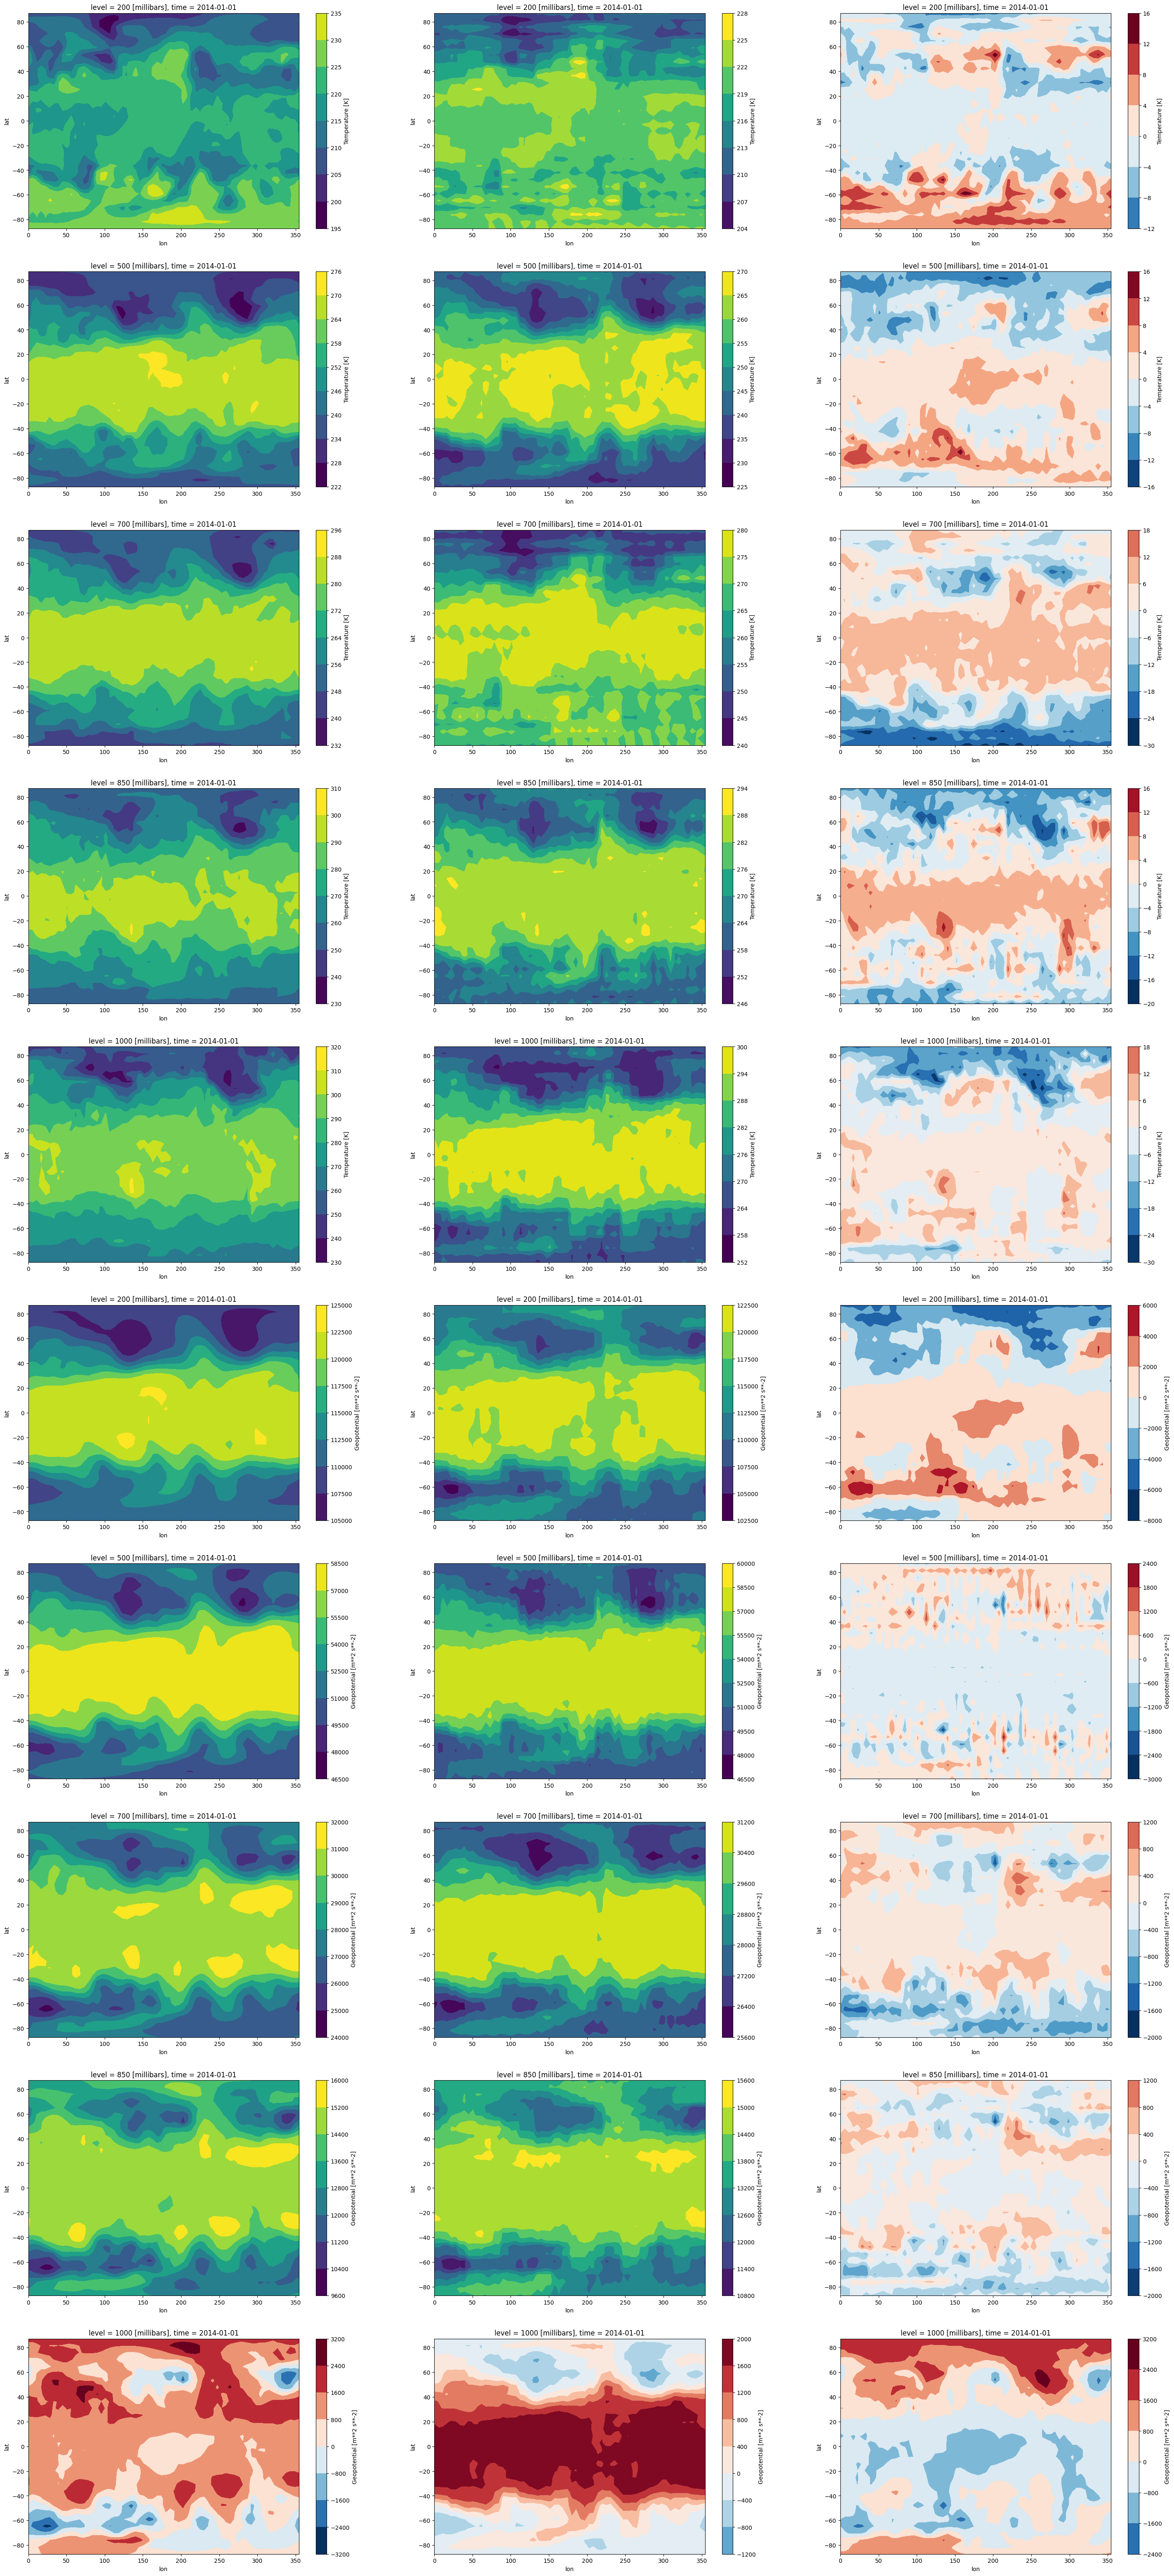

In [167]:
fig1 = matplotlib.pyplot.figure(figsize=(36,80))
ix1 = 0
for v1 in var_subset:
    for p1 in pl_subset:
        ax1 = fig1.add_subplot(10,3,ix1*3+1)
        current_input = sample_input[v1].sel(level=p1)
        current_input.plot.contourf(ax=ax1)
        ax1 = fig1.add_subplot(10,3,ix1*3+2)
        current_pred = sample_pred[v1].sel(level=p1)
        current_pred.plot.contourf(ax=ax1)
        ax1 = fig1.add_subplot(10,3,ix1*3+3)
        (current_input-current_pred).plot.contourf(ax=ax1)
        ix1 +=1
    

### Evaluate the results
Now we want to compare our samples to the predictor. We will start looking at RMSE, using the scores package for evaluation. 

The steps are as follows:
- Loop through batches in the validation data set
- For each batch
  - Make a prediction
  - Denormalise the input and prediction
  - Use scores to calculate RMSE
  - Add to cumulative total
  - Normalise for the number of samples

In [126]:
import scores

In [168]:
len(wb_val_loader)

1096

In [171]:
wb_val_ds._ds_norm.dims

FrozenMappingWarningOnValuesAccess({'time': 17521, 'level': 5, 'lat': 32, 'lon': 64})

In [182]:
metric_dict = { (v1,p1):0.0 for v1 in var_subset for p1 in pl_subset}

In [201]:
num_batches_val = len(wb_val_loader)

In [203]:
%%time
scores_total = None
for batch_ix_val, X_batch_val in enumerate(wb_val_loader):
    rmse_batch = scores.continuous.rmse(
        denormalise_tensor(X_batch_val, std_vec, mean_vec, da_skeletons)[1],
        denormalise_tensor(ae_model.forward(X_batch_val), std_vec, mean_vec, da_skeletons)[1],
        preserve_dims='level',
    )
    if scores_total is None:
        scores_total = rmse_batch
    else:
        scores_total += rmse_batch
            
scores_total /= num_batches_val 

CPU times: user 16min 40s, sys: 1min 41s, total: 18min 22s
Wall time: 13min 59s


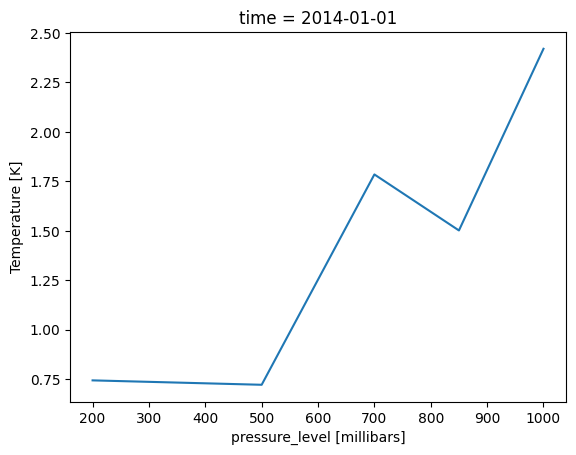

In [207]:
scores_total['temperature'].plot()

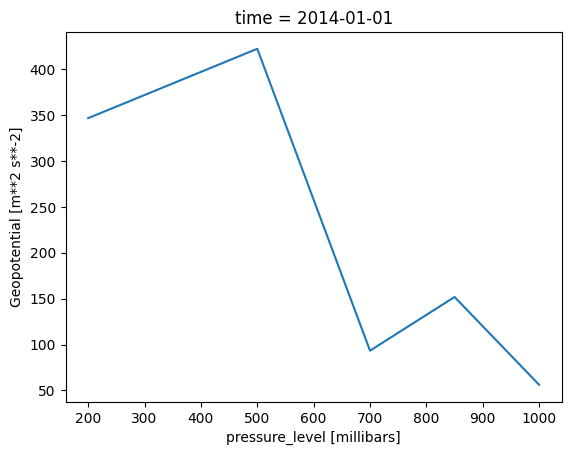

In [209]:
scores_total['geopotential'].plot()

## Exercises
* Try to vary the input para

